In [2]:
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [1]:
import torch, os
print("CUDA available:", torch.cuda.is_available())
print("CUDA device count:", torch.cuda.device_count())
if torch.cuda.is_available():
    print("GPU name:", torch.cuda.get_device_name(0))
print("CUDA_VISIBLE_DEVICES:", os.environ.get("CUDA_VISIBLE_DEVICES"))



A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.2.6 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "/gpfs/scratch/yg3030/miniconda3/envs/pyskl_py310/lib/python3.10/runpy.py", line 196, in _run_module_as_main
    return _run_code(code, main_globals, None,
  File "/gpfs/scratch/yg3030/miniconda3/envs/pyskl_py310/lib/python3.10/runpy.py", line 86, in _run_code
    exec(code, run_globals)
  File "/gpfs/scratch/yg3030/miniconda3/envs/pyskl_py310/lib/python3.10/site-packages/ipykernel_launcher.py", line 18, in <module>
    app.launch_new_instance()
  File "/gpfs/scratch/yg3030/miniconda3/envs/pyskl_py310/lib/python3.10

CUDA available: False
CUDA device count: 0
CUDA_VISIBLE_DEVICES: None


/gpfs/scratch/yg3030/miniconda3/envs/pyskl_py310/lib/python3.10/site-packages/torch/cuda/__init__.py:611: UserWarning: Can't initialize NVML
  warnings.warn("Can't initialize NVML")


In [ ]:
with open('./InfActPrimitive/2d/InfAct_plus.pkl', 'rb') as f:
    InfAct_2d = pickle.load(f)

with open('./InfActPrimitive/3d/InfAct_plus.pkl', 'rb') as f:
    InfAct_3d = pickle.load(f)

: 

In [5]:
print(f"{len(InfAct_2d.get('annotations', []))} items in total")
print(InfAct_2d.keys())

split = InfAct_2d.get('split', {})
print(split.keys()) 

for k, v in split.items():
    print(f"{k}: {len(v)} items")

792 items in total
dict_keys(['split', 'annotations'])
dict_keys(['train', 'val'])
train: 400 items
val: 392 items


In [6]:
for k, v in split.items():
    print(f"{k}: {v[:5]}")

train: ['YouTube_001_posture1', 'YouTube_001_posture3', 'YouTube_002_posture1', 'YouTube_002_posture3', 'YouTube_004_posture1']
val: ['D01_p0047_47_0', 'D01_p0071_71_0', 'D01_s0006_81_0', 'D01_p0045_45_0', 'D01_p0017_17_0']


In [7]:
first2d = InfAct_2d['annotations'][501]
print("\nExample 2D annotation keys:")
for k,v in first2d.items():
    if isinstance(v, (list, np.ndarray)):
        print(f"  {k}: type={type(v)}, shape={np.shape(v)}")
    else:
        print(f"  {k}: {v}")


Example 2D annotation keys:
  pos_number: 7
  start_frame: 1625
  end_frame: 2065
  frame_dir: D02_1_Posture 7
  total_frames: 440
  img_shape: (1080, 1920)
  original_shape: (1080, 1920)
  pos_label: Sitting
  source: CAREER_D02
  keypoint: type=<class 'numpy.ndarray'>, shape=(1, 440, 17, 2)
  keypoint_score: type=<class 'numpy.ndarray'>, shape=(1, 440, 17)
  label: 2


In [8]:
first3d = InfAct_3d['annotations'][0]
print("\nExample 3D annotation keys:")
for k,v in first3d.items():
    if isinstance(v, (list, np.ndarray)):
        print(f"  {k}: type={type(v)}, shape={np.shape(v)}")
    else:
        print(f"  {k}: {v}")


Example 3D annotation keys:
  start_frame: 0
  end_frame: 62
  pos_label: Prone
  frame_dir: YouTube_001_posture1
  img_shape: (1080, 1920)
  original_shape: (1080, 1920)
  total_frames: 62
  keypoint: type=<class 'numpy.ndarray'>, shape=(1, 62, 17, 3)
  source: youtube
  label: 1


In [9]:
pos_labels_2d = [ann.get('pos_label','') for ann in InfAct_2d['annotations']]
labels_2d = [ann.get('label','') for ann in InfAct_2d['annotations']]
print("\nUnique pos_label (2D):", np.unique(pos_labels_2d))
print("Unique action label (2D):", np.unique(labels_2d))


Unique pos_label (2D): ['All-fours' 'Prone' 'Sitting' 'Standing' 'Supine']
Unique action label (2D): [0 1 2 3 4]


pos_label counts (2D):
 Prone        253
Supine       199
Sitting      149
Standing     100
All-fours     91
dtype: int64


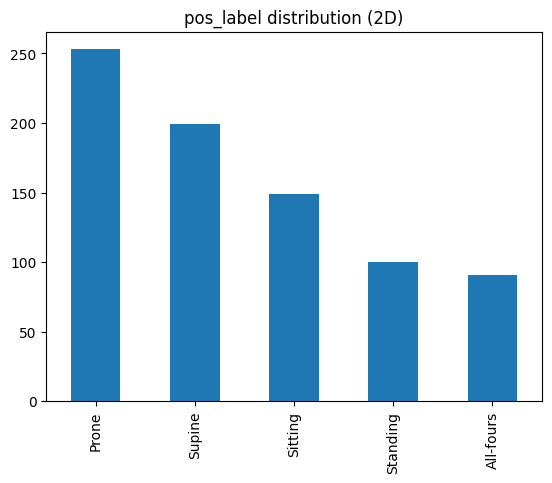

In [10]:
pos_counts_2d = pd.Series([a.get('pos_label','') for a in InfAct_2d.get('annotations', [])]).value_counts()
print("pos_label counts (2D):\n", pos_counts_2d)

# Plot counts
pd.Series(pos_labels_2d).value_counts().plot.bar(title="pos_label distribution (2D)")
plt.show()

action label counts (2D):
 1    253
0    199
2    149
3    100
4     91
dtype: int64


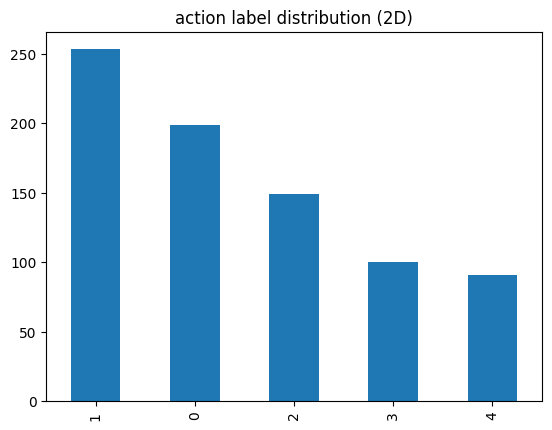

In [11]:
label_counts_2d = pd.Series([a.get('label','') for a in InfAct_2d.get('annotations', [])]).value_counts()
print("action label counts (2D):\n", label_counts_2d)

# Plot counts
pd.Series(labels_2d).value_counts().plot.bar(title="action label distribution (2D)")
plt.show()

In [12]:
def get_layout(layout: str) -> None:
    """Initialize the layout of candidates."""

    if layout == 'openpose':
        num_node = 18
        inward = [(4, 3), (3, 2), (7, 6), (6, 5), (13, 12), (12, 11),
                        (10, 9), (9, 8), (11, 5), (8, 2), (5, 1), (2, 1),
                        (0, 1), (15, 0), (14, 0), (17, 15), (16, 14)]
        center = 1
    elif layout == 'human3.6m':
        num_node = 17
        inward = [(10, 9), (9, 8), (8,7), (7,0), (13, 12), (12, 11), (11, 8),
                  (16, 15), (15, 14), (14, 8),
                  (13, 12), (12, 11), (11, 8),
                  (3, 2), (2,1), (1,0),
                  (6,5), (5,4), (4,0)]
        center = 0
    elif layout == 'nturgb+d':
        num_node = 25
        neighbor_base = [(1, 2), (2, 21), (3, 21), (4, 3), (5, 21), (6, 5),
                            (7, 6), (8, 7), (9, 21), (10, 9), (11, 10),
                            (12, 11), (13, 1), (14, 13), (15, 14), (16, 15),
                            (17, 1), (18, 17), (19, 18), (20, 19), (22, 8),
                            (23, 8), (24, 12), (25, 12)]
        inward = [(i - 1, j - 1) for (i, j) in neighbor_base]
        center = 21 - 1
    elif layout == 'coco':
        num_node = 17
        inward = [(15, 13), (13, 11), (16, 14), (14, 12), (11, 5),
                        (12, 6), (9, 7), (7, 5), (10, 8), (8, 6), (5, 0),
                        (6, 0), (1, 0), (3, 1), (2, 0), (4, 2)]
        center = 0
    elif isinstance(layout, dict):
        num_node = layout['num_node']
        inward = layout['inward']
        center = layout['center']
    else:
        raise ValueError(f'Do Not Exist This Layout: {layout}')
    return num_node, inward, center

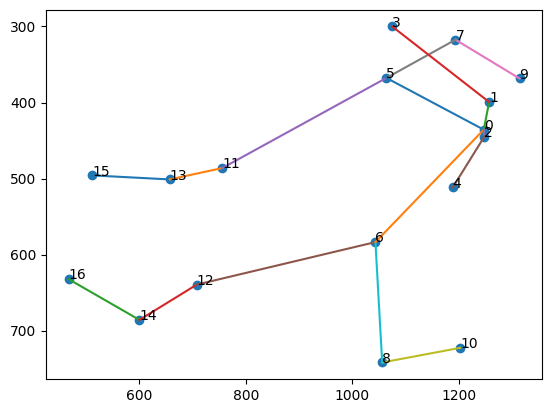

In [13]:
sample_2d = InfAct_2d['annotations'][400]['keypoint'][0,0]
num_nodes, inward, center = get_layout('coco')
assert sample_2d.shape[0] == num_nodes
Xs = sample_2d[:,0]
Ys = sample_2d[:,1]
fig, ax = plt.subplots()
ax.invert_yaxis()
ax.scatter(Xs, Ys)
for i, joint in enumerate(sample_2d):
    ax.annotate(xy=joint, text=i)
for bone in inward:
    ax.plot((Xs[bone[0]], Xs[bone[1]]), (Ys[bone[0]], Ys[bone[1]]))

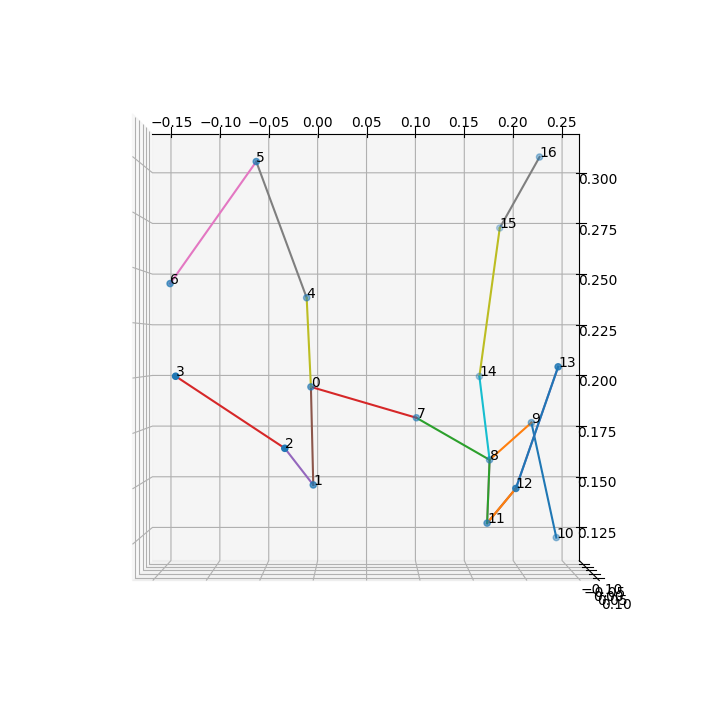

In [14]:
sample_3d = InfAct_3d['annotations'][400]['keypoint'][0,0]
num_nodes, inward, center = get_layout('human3.6m')
assert sample_3d.shape[0] == num_nodes
Xs = sample_3d[:,0]
Ys = sample_3d[:,1]
Zs = sample_3d[:,2]
fig = plt.figure(figsize=(16, 9))
ax = fig.add_subplot(projection='3d')
ax.scatter(Xs, Ys, Zs)
for i, joint in enumerate(sample_3d):
    ax.text(x=joint[0], y=joint[1], z=joint[2],  s=f'{i}') 
for bone in inward:
    ax.plot((Xs[bone[0]], Xs[bone[1]]), (Ys[bone[0]], Ys[bone[1]]), (Zs[bone[0]], Zs[bone[1]]))
ax.view_init(elev=90, azim=-90)

In [ ]:
import os, sys, pickle
import numpy as np
import torch
import matplotlib.pyplot as plt
import imageio.v2 as imageio

print("Python:", sys.version)
print("Executable:", sys.executable)
print("Torch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

# Notebook is at root/Data/infact_eda.ipynb
# If CWD is root/Data, repo root is .. ; if CWD is repo root, this still works.
REPO_ROOT = os.path.abspath(os.path.join(os.getcwd(), ".."))
print("REPO_ROOT =", REPO_ROOT)

PY_SKL_ROOT = os.path.join(REPO_ROOT, "pyskl")

CFG_PATH  = os.path.join(PY_SKL_ROOT, "configs/dgstgcn/infact_primitive_2dkp/j.py")
CKPT_PATH = os.path.join(PY_SKL_ROOT, "work_dirs/dgstgcn/infact_primitive_2dkp/j/latest.pth")
INFANT_PKL = os.path.join(REPO_ROOT, "Data/InfActPrimitive/2d/InfAct_plus_withZ_noscore.pkl")

for p in [CFG_PATH, CKPT_PATH, INFANT_PKL]:
    print("Check:", p, "=>", os.path.exists(p))
    assert os.path.exists(p), f"Missing: {p}"

# Make sure pyskl repo is importable
if PY_SKL_ROOT not in sys.path:
    sys.path.insert(0, PY_SKL_ROOT)
print("sys.path[0]:", sys.path[0])

/gpfs/scratch/yg3030/miniconda3/envs/pyskl/lib/python3.7/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


REPO_ROOT = /gpfs/scratch/yg3030/Video-Based-Infant-Action-Recognition


In [ ]:
from mmcv import Config
from mmcv.runner import load_checkpoint
from pyskl.models import build_model

cfg = Config.fromfile(CFG_PATH)

# Use GPU if available
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

model = build_model(cfg.model)
_ = load_checkpoint(model, CKPT_PATH, map_location="cpu")  # safer load on cpu
model = model.to(device)
model.eval()

print("Model loaded.")
print("num_classes:", cfg.model["cls_head"]["num_classes"])

load checkpoint from local path: /gpfs/scratch/yg3030/Video-Based-Infant-Action-Recognition/pyskl/work_dirs/dgstgcn/infact_primitive_2dkp/j/latest.pth
Model loaded.
Device: cpu
Config num_classes: 5


In [ ]:
from pyskl.datasets.pipelines import Compose

# Copy test pipeline from config (closest to tools/test.py behavior)
pipe_cfg = cfg.test_pipeline.copy()

# For demo speed: force num_clips=1 if UniformSample exists
for t in pipe_cfg:
    if isinstance(t, dict) and t.get("type") == "UniformSample":
        t["num_clips"] = 1

demo_pipeline = Compose(pipe_cfg)
print("Demo pipeline steps:")
for s in pipe_cfg:
    print("  -", s.get("type") if isinstance(s, dict) else s)

In [ ]:
# COCO skeleton edges (same as your EDA)
COCO_INWARD = [
    (15, 13), (13, 11), (16, 14), (14, 12), (11, 5),
    (12, 6), (9, 7), (7, 5), (10, 8), (8, 6), (5, 0),
    (6, 0), (1, 0), (3, 1), (2, 0), (4, 2)
]

LABEL_NAMES = ["Supine", "Prone", "Sitting", "Standing", "All-fours"]  # label 0..4
LABEL_COLORS = {
    0: (0.20, 0.55, 0.90),
    1: (0.90, 0.35, 0.25),
    2: (0.25, 0.70, 0.35),
    3: (0.60, 0.40, 0.85),
    4: (0.95, 0.75, 0.20),
}

def draw_skeleton_2d(ax, kp_2d, color=(1, 0, 0), lw=2, s=18):
    xs = kp_2d[:, 0]
    ys = kp_2d[:, 1]
    ax.scatter(xs, ys, c=[color], s=s)
    for a, b in COCO_INWARD:
        ax.plot([xs[a], xs[b]], [ys[a], ys[b]], c=color, lw=lw)
    ax.invert_yaxis()
    ax.set_axis_off()

def window_at_t(kp_1TVC, t, clip_len=48):
    """
    kp_1TVC: (1, T, 17, 2)
    return:  (1, clip_len, 17, 2)
    """
    T = kp_1TVC.shape[1]
    start = t - (clip_len - 1)
    idxs = np.arange(start, t + 1)
    idxs = np.clip(idxs, 0, T - 1)
    return kp_1TVC[:, idxs, :, :]

@torch.inference_mode()
def predict_window(window_1TVC, img_shape, ori_shape):
    """
    window_1TVC: (1, clip_len, 17, 2) numpy
    Returns: pred(int), conf(float), probs(np.ndarray)
    """
    clip_len = window_1TVC.shape[1]

    # Provide required keys for pyskl pipeline
    sample = {
        "frame_dir": "demo_clip",
        "label": 0,  # dummy
        "total_frames": clip_len,
        "img_shape": img_shape,
        "original_shape": ori_shape,
        "keypoint": window_1TVC.astype(np.float32),
    }

    # Some transforms may expect keypoint_score; provide dummy
    sample["keypoint_score"] = np.ones((1, clip_len, 17), dtype=np.float32)

    sample = demo_pipeline(sample)

    # After pipeline, sample["keypoint"] should be torch tensor
    keypoint = sample["keypoint"]

    # Normalize to (B, num_clips, num_person, T, V, C)
    # Usually FormatGCNInput already makes (num_clips, num_person, T, V, C)
    if keypoint.dim() == 5:
        keypoint = keypoint.unsqueeze(0)  # add batch -> (1, num_clips, num_person, T, V, C)
    elif keypoint.dim() == 6:
        pass
    else:
        raise RuntimeError(f"Unexpected keypoint tensor shape: {tuple(keypoint.shape)}")

    keypoint = keypoint.to(device)

    out = model(return_loss=False, keypoint=keypoint)

    # out may be tensor (B, num_classes) or list
    if isinstance(out, (list, tuple)):
        out = out[0]

    if isinstance(out, np.ndarray):
        logits = torch.from_numpy(out)
    else:
        logits = out.detach().cpu()

    logits = logits.squeeze()
    if logits.ndim == 2:
        logits = logits[0]  # take first in batch

    probs = torch.softmax(logits, dim=-1).numpy()
    pred = int(probs.argmax())
    conf = float(probs[pred])
    return pred, conf, probs

# --- Load data
with open(INFANT_PKL, "rb") as f:
    infact = pickle.load(f)

split = infact["split"]
annos = infact["annotations"]

# Pick the first train sample
first_id = split["train"][0]
idx = next(i for i, a in enumerate(annos) if a.get("frame_dir") == first_id)
ann = annos[idx]

kp_full = ann["keypoint"]  # (1, T, 17, 2)
T = kp_full.shape[1]
img_shape = ann.get("img_shape", (1080, 1920))
ori_shape = ann.get("original_shape", (1080, 1920))

print("Picked:", ann.get("frame_dir"), "| source:", ann.get("source"))
print("GT:", ann.get("pos_label"), ann.get("label"), "| keypoint:", kp_full.shape, "| T:", T)

# --- Demo parameters
CLIP_LEN   = 48
FPS        = 10
STEP       = 2     # increase to 3/4 if slow
MAX_FRAMES = 200   # keep small to avoid huge gif
OUT_GIF    = os.path.join(REPO_ROOT, "infact_dgstgcn_demo.gif")

frames = []
for t in range(0, min(T, MAX_FRAMES), STEP):
    w = window_at_t(kp_full, t, CLIP_LEN)
    pred, conf, _ = predict_window(w, img_shape=img_shape, ori_shape=ori_shape)

    fig, ax = plt.subplots(figsize=(7, 5))
    color = LABEL_COLORS[pred]

    draw_skeleton_2d(ax, kp_full[0, t], color=color, lw=2, s=18)

    txt = f"t={t:04d} | pred={LABEL_NAMES[pred]} ({conf:.2f})"
    ax.text(
        0.02, 0.98, txt,
        transform=ax.transAxes,
        ha="left", va="top",
        fontsize=12,
        bbox=dict(facecolor="white", alpha=0.8, edgecolor="none")
    )

    fig.canvas.draw()
    img = np.frombuffer(fig.canvas.tostring_rgb(), dtype=np.uint8)
    img = img.reshape(fig.canvas.get_width_height()[::-1] + (3,))
    frames.append(img)
    plt.close(fig)

imageio.mimsave(OUT_GIF, frames, fps=FPS)
print("Saved GIF:", OUT_GIF)

Picked frame_dir: YouTube_001_posture1
Source: youtube
GT pos_label: Prone GT label: 1
Keypoint shape: (1, 62, 17, 3)
Total frames: 62
